---
Machine Learning con PySpark y Docker

---


PARCIAL FINAL · Componente práctico


# Bloque 1 · Análisis exploratorio con PySpark

In [ ]:
# /////////// librerias y dependencias ///////////
!pip install pyspark
!pip install pycaret
from pyspark.sql import SparkSession
from google.colab import files

In [ ]:
# /////////// Carga de datos ///////////
spark = SparkSession.builder \
    .appName("LeerCSV") \
    .getOrCreate()

uploaded = files.upload()

df = spark.read.csv(
    "rips_200k_departamento.csv",
    header=True,
    inferSchema=True,
    sep=",",
    encoding="utf-8"
)



Saving rips_200k_departamento.csv to rips_200k_departamento (7).csv


## 1.1 Cargar el dataset elegido con PySpark, mostrando el esquema, conteo de registros y primeras filas.


In [ ]:
# EDA

print("\n" + "="*60)
print("INFORMACIÓN GENERAL DEL DATASET RIPS")
print("="*60)

# shape
filas = df.count()
columnas = len(df.columns)

print(f"\n Total de registros : {filas:,}")
print(f"Total de columnas  : {columnas}")

print("\n Nombres de columnas:")
for i, c in enumerate(df.columns, 1):
    print(f"   {i}. {c}")

# estructura


print("\n" + "="*60)
print("ESQUEMA Y TIPOS DE DATOS")
print("="*60)

df.printSchema()

# vista previa


print("\n" + "="*60)
print("PRIMERAS FILAS DEL DATASET")
print("="*60)

df.show(5, truncate=False)

# Resultado


print("\n" + "="*60)
print("RESUMEN DE EXPLORACIÓN")
print("="*60)





INFORMACIÓN GENERAL DEL DATASET RIPS

 Total de registros : 200,000
Total de columnas  : 6

 Nombres de columnas:
   1. departamento
   2. municipio
   3. a_o
   4. tipoatencion
   5. diagnostico
   6. numeroatenciones

ESQUEMA Y TIPOS DE DATOS
root
 |-- departamento: string (nullable = true)
 |-- municipio: string (nullable = true)
 |-- a_o: integer (nullable = true)
 |-- tipoatencion: string (nullable = true)
 |-- diagnostico: string (nullable = true)
 |-- numeroatenciones: integer (nullable = true)


PRIMERAS FILAS DEL DATASET
+--------------+--------------------+----+-----------------------+--------------------------------------------------------------------------------+----------------+
|departamento  |municipio           |a_o |tipoatencion           |diagnostico                                                                     |numeroatenciones|
+--------------+--------------------+----+-----------------------+-------------------------------------------------------------------

# 1.2  Aplicar al menos tres transformaciones (filter, groupBy, withColumn, join) que respondan apreguntas analíticas concretas.


## 1.2.1 **¿Qué municipios presentan más de 100 atenciones registradas?**

In [ ]:
from pyspark.sql.functions import *

print("\n" + "="*70)
print("MUNICIPIOS CON MÁS DE 100 ATENCIONES")
print("="*70)

df_altas = df.filter(col("numeroatenciones") > 100)

print(f"Registros encontrados: {df_altas.count()}")

df_altas.select(
    "departamento",
    "municipio",
    "numeroatenciones"
).show(10, truncate=False)


MUNICIPIOS CON MÁS DE 100 ATENCIONES
Registros encontrados: 11543
+-----------------+---------------------+----------------+
|departamento     |municipio            |numeroatenciones|
+-----------------+---------------------+----------------+
|11 - Bogotá, D.C.|11001 - Bogotá, D.C. |509             |
|13 - Bolívar     |13894 - Zambrano     |105             |
|05 - Antioquia   |05001 - Medellín     |207             |
|23 - Córdoba     |23660 - Sahagún      |304             |
|05 - Antioquia   |05001 - Medellín     |394             |
|05 - Antioquia   |05697 - El Santuario |225             |
|05 - Antioquia   |05147 - Carepa       |49973           |
|15 - Boyacá      |15500 - Oicatá       |106             |
|15 - Boyacá      |15572 - Puerto Boyacá|1403            |
|11 - Bogotá, D.C.|11001 - Bogotá, D.C. |5129            |
+-----------------+---------------------+----------------+
only showing top 10 rows


**Se evidencia que la concentración de atenciones se centra en ciudades principales, lo que guarda realción con la cobertura del sistema de salud nacional.**

# 1.2.2 **¿Qué departamentos concentran la mayor cantidad de atenciones?**

In [ ]:
print("\n" + "="*70)
print("TOTAL DE ATENCIONES POR DEPARTAMENTO")
print("="*70)

depto_group = df.groupBy("departamento") \
    .agg(
        sum("numeroatenciones").alias("total_atenciones")
    ) \
    .orderBy(col("total_atenciones").desc())

depto_group.show(truncate=False)


TOTAL DE ATENCIONES POR DEPARTAMENTO
+-----------------+----------------+
|departamento     |total_atenciones|
+-----------------+----------------+
|05 - Antioquia   |7301551         |
|11 - Bogotá, D.C.|6516087         |
|08 - Atlántico   |2572869         |
|13 - Bolívar     |1370007         |
|20 - Cesar       |1258819         |
|23 - Córdoba     |1176470         |
|-1 - NO DEFINIDO |1082126         |
|15 - Boyacá      |827623          |
|19 - Cauca       |748649          |
|17 - Caldas      |481641          |
|25 - Cundinamarca|263077          |
|18 - Caquetá     |192228          |
+-----------------+----------------+



**Antioquia y Bogotá D.C. concentran la mayor cantidad de atenciones médicas, lo que refleja una alta demanda de servicios de salud y diferencias regionales importantes frente a otros departamentos.**

# 1.2.3 **¿Cómo clasificar el volumen de atención médica?**

In [ ]:
print("\n" + "="*70)
print("CLASIFICACIÓN DEL NIVEL DE ATENCIÓN")
print("="*70)

df_nuevo = df.withColumn(
    "nivel_atencion",
    when(col("numeroatenciones") >= 100, "ALTA")
    .when(col("numeroatenciones") >= 50, "MEDIA")
    .otherwise("BAJA")
)

df_nuevo.select(
    "departamento",
    "municipio",
    "numeroatenciones",
    "nivel_atencion"
).show(15, truncate=False)


CLASIFICACIÓN DEL NIVEL DE ATENCIÓN
+-----------------+--------------------------+----------------+--------------+
|departamento     |municipio                 |numeroatenciones|nivel_atencion|
+-----------------+--------------------------+----------------+--------------+
|08 - Atlántico   |08001 - Barranquilla      |1               |BAJA          |
|05 - Antioquia   |05284 - Frontino          |1               |BAJA          |
|18 - Caquetá     |18029 - Albania           |1               |BAJA          |
|23 - Córdoba     |23807 - Tierralta         |1               |BAJA          |
|13 - Bolívar     |13001 - Cartagena         |1               |BAJA          |
|23 - Córdoba     |23090 - Canalete          |1               |BAJA          |
|15 - Boyacá      |15759 - Sogamoso          |2               |BAJA          |
|13 - Bolívar     |13667 - San Martín De Loba|2               |BAJA          |
|19 - Cauca       |19318 - Guapi             |2               |BAJA          |
|23 - Córdoba  

**La mayoría de los municipios fueron clasificados con un nivel de atención bajo, ya que presentan pocos registros de atenciones. Sin embargo, ciudades principales como Bogotá D.C. muestran niveles de atención altos, reflejando una mayor concentración y demanda de servicios de salud.**

# 1.3 EDA

## 1.3.1 describe()

In [ ]:
df.describe().show()

+-------+-----------------+----------------+--------------------+------------+--------------------+------------------+
|summary|     departamento|       municipio|                 a_o|tipoatencion|         diagnostico|  numeroatenciones|
+-------+-----------------+----------------+--------------------+------------+--------------------+------------------+
|  count|           200000|          200000|              200000|      200000|              200000|            200000|
|   mean|             NULL|            NULL|              2019.0|        NULL|                NULL|        118.955735|
| stddev|             NULL|            NULL|1.116506016658395...|        NULL|                NULL|6751.8428450131205|
|    min| -1 - NO DEFINIDO|-1 - No Definido|                2019|   CONSULTAS|     1 - NO DEFINIDO|                 1|
|    max|25 - Cundinamarca| 25898 - Zipacón|                2019|   URGENCIAS|Z999 - DEPENDENCI...|           2356184|
+-------+-----------------+----------------+----

## 1.3.2 summary()

In [ ]:
df.summary().show()

+-------+-----------------+----------------+--------------------+------------+--------------------+------------------+
|summary|     departamento|       municipio|                 a_o|tipoatencion|         diagnostico|  numeroatenciones|
+-------+-----------------+----------------+--------------------+------------+--------------------+------------------+
|  count|           200000|          200000|              200000|      200000|              200000|            200000|
|   mean|             NULL|            NULL|              2019.0|        NULL|                NULL|        118.955735|
| stddev|             NULL|            NULL|1.116506016658395...|        NULL|                NULL|6751.8428450131205|
|    min| -1 - NO DEFINIDO|-1 - No Definido|                2019|   CONSULTAS|     1 - NO DEFINIDO|                 1|
|    25%|             NULL|            NULL|                2019|        NULL|                NULL|                 1|
|    50%|             NULL|            NULL|    

## 1.3.3 percentiles

In [ ]:
percentiles = df.approxQuantile(
    "numeroatenciones",
    [0.25, 0.50, 0.75],
    0.01
)

print(f"🔹 Percentil 25% : {percentiles[0]}")
print(f"🔹 Mediana 50%   : {percentiles[1]}")
print(f"🔹 Percentil 75% : {percentiles[2]}")

🔹 Percentil 25% : 1.0
🔹 Mediana 50%   : 3.0
🔹 Percentil 75% : 10.0


**Los percentiles muestran que el 25% de los registros tienen hasta 1 atención, el 50% hasta 3 atenciones y el 75% hasta 10 atenciones. Esto indica que la mayoría de los registros presentan una cantidad baja de atenciones.**

## 1.3.4 Conteos por categoría

In [ ]:
conteo_tipo = df.groupBy("tipoatencion") \
    .count() \
    .orderBy(col("count").desc())

conteo_tipo.show(truncate=False)

+-----------------------+-----+
|tipoatencion           |count|
+-----------------------+-----+
|CONSULTAS              |94179|
|PROCEDIMIENTOS DE SALUD|68559|
|URGENCIAS              |19522|
|HOSPITALIZACIONES      |17740|
+-----------------------+-----+



# 1.4 Análisis de datos faltantes

## 1.4.1 Datos faltantes

In [ ]:

from pyspark.sql.functions import *
from pyspark.sql.types import *

columnas_numericas = [
    field.name
    for field in df.schema.fields
    if isinstance(field.dataType, (IntegerType, DoubleType, FloatType, LongType))
]

nulos = df.select([

    count(
        when(
            col(c).isNull() |
            (isnan(c) if c in columnas_numericas else lit(False)),
            c
        )
    ).alias(c)

    for c in df.columns
])

nulos.show(truncate=False)



+------------+---------+---+------------+-----------+----------------+
|departamento|municipio|a_o|tipoatencion|diagnostico|numeroatenciones|
+------------+---------+---+------------+-----------+----------------+
|0           |0        |0  |0           |0          |0               |
+------------+---------+---+------------+-----------+----------------+



## 1.4.2 Duplicados

In [ ]:
duplicados = df.count() - df.dropDuplicates().count()
print(f"Cantidad de duplicados encontrados: {duplicados}")

Cantidad de duplicados encontrados: 7588


## 1.4.3 Valores atípicos

In [ ]:
Q1 = percentiles[0]
Q3 = percentiles[2]

IQR = Q3 - Q1

limite_inferior = Q1 - (1.5 * IQR)
limite_superior = Q3 + (1.5 * IQR)

print(f"Límite inferior: {limite_inferior}")
print(f"Límite superior: {limite_superior}")

outliers = df.filter(
    (col("numeroatenciones") < limite_inferior) |
    (col("numeroatenciones") > limite_superior)
)

print(f"Valores atípicos encontrados: {outliers.count()}")

Límite inferior: -12.5
Límite superior: 23.5
Valores atípicos encontrados: 29883


# 1.5 Visualizaciones

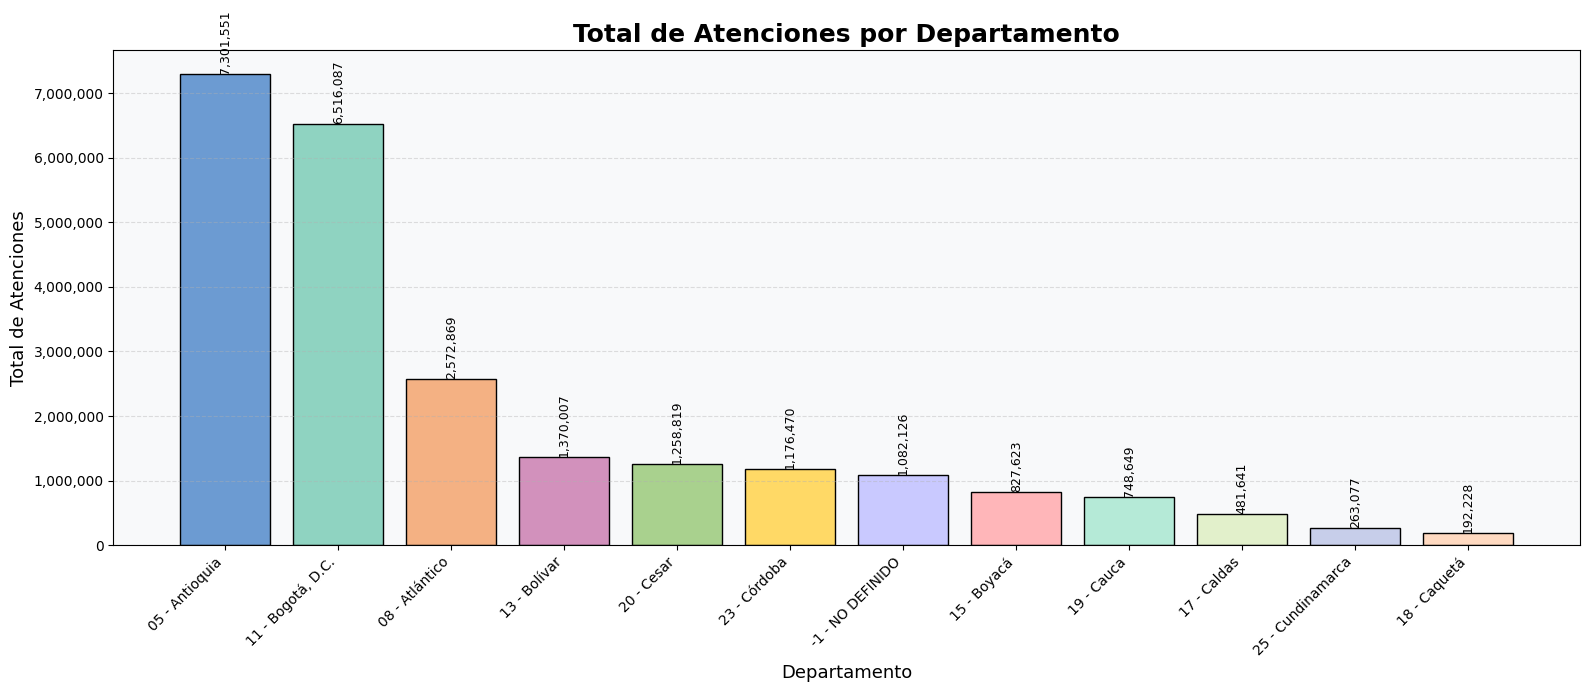

In [ ]:

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Convertir a Pandas
depto_pd = depto_group.toPandas()

depto_pd = depto_pd.sort_values(
    by="total_atenciones",
    ascending=False
)


plt.figure(figsize=(16,7))

colores = [
    "#6C9BD2",
    "#8FD3C1",
    "#F4B183",
    "#D291BC",
    "#A9D18E",
    "#FFD966",
    "#C9C9FF",
    "#FFB6B9",
    "#B5EAD7",
    "#E2F0CB",
    "#C7CEEA",
    "#FFDAC1"
]

bars = plt.bar(
    depto_pd["departamento"],
    depto_pd["total_atenciones"],
    color=colores[:len(depto_pd)],
    edgecolor="black",
    linewidth=1
)


for bar in bars:

    altura = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        altura,
        f'{altura:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9,
        rotation=90
    )

plt.title(
    "Total de Atenciones por Departamento",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    "Departamento",
    fontsize=13
)

plt.ylabel(
    "Total de Atenciones",
    fontsize=13
)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{int(x):,}')
)

plt.xticks(
    rotation=45,
    ha='right',
    fontsize=10
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

plt.gca().set_facecolor('#F8F9FA')

plt.tight_layout()

plt.show()



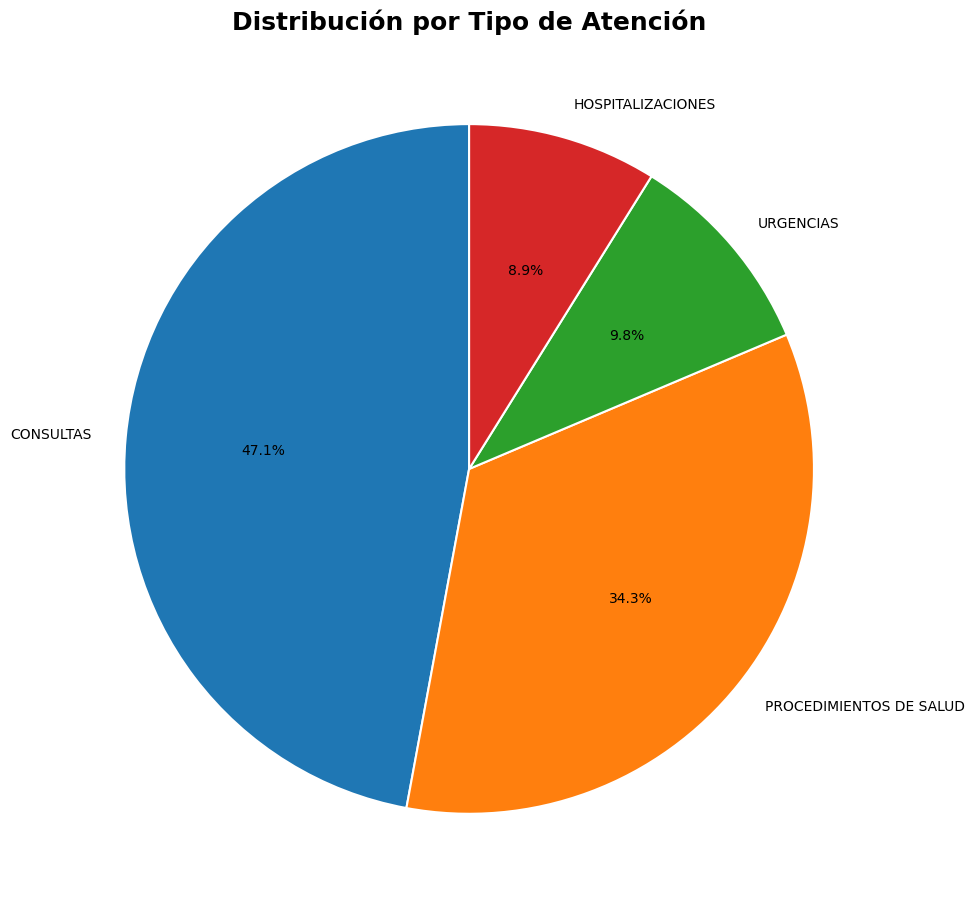

In [ ]:

import matplotlib.pyplot as plt

tipo_pd = conteo_tipo.toPandas()

tipo_pd = tipo_pd.sort_values(
    by="count",
    ascending=False
)

plt.figure(figsize=(10,10))

plt.pie(
    tipo_pd["count"],
    labels=tipo_pd["tipoatencion"],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

plt.title(
    "Distribución por Tipo de Atención",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()

plt.show()



# 1.6 Redactar tres conclusiones cuantitativas que respondan a preguntas analíticas del dominio del dato

 ---
 - Los departamentos con mayor volumen de registros concentran una proporción significativa de las atenciones médicas, evidenciando desigualdades regionales en la demanda de servicios de salud.

---

 - La distribución de la variable numeroatenciones presenta asimetría positiva, indicando que la mayoría de registros tienen pocas atenciones, mientras unos pocos presentan valores extremadamente altos.

---


- La detección de valores atípicos mostró registros muy superiores al comportamiento promedio, lo cual puede estar asociado a eventos epidemiológicos, errores de captura o municipios con alta concentración poblacional.
---


# Bloque 2 · Machine Learning con Spark ML

## Parte A

In [ ]:

from pyspark.ml.feature import (
    StringIndexer,
    OneHotEncoder,
    VectorAssembler,
    StandardScaler
)

from pyspark.ml import Pipeline

# Variables categóricas
columnas_categoricas = [
    "departamento",
    "municipio",
    "tipoatencion"
]

# StringIndexer
indexadores = [
    StringIndexer(
        inputCol=col,
        outputCol=f"{col}_index"
    )
    for col in columnas_categoricas
]

# One Hot Encoding
encoder = OneHotEncoder(
    inputCols=[
        f"{col}_index"
        for col in columnas_categoricas
    ],

    outputCols=[
        f"{col}_vec"
        for col in columnas_categoricas
    ]
)

# Variables numéricas
assembler_numerico = VectorAssembler(
    inputCols=["numeroatenciones"],
    outputCol="numerical_features"
)

# Standard Scaler
scaler = StandardScaler(
    inputCol="numerical_features",
    outputCol="scaled_numerical_features",
    withMean=True,
    withStd=True
)

# Variables finales
assembler_final = VectorAssembler(
    inputCols=[
        "departamento_vec",
        "municipio_vec",
        "tipoatencion_vec",
        "scaled_numerical_features"
    ],

    outputCol="features"
)

# Pipeline
pipeline = Pipeline(stages=

    indexadores +

    [
        encoder,
        assembler_numerico,
        scaler,
        assembler_final
    ]
)

# Entrenar
pipeline_model = pipeline.fit(df)

# Transformar
df_preparado = pipeline_model.transform(df)

# Resultado
df_preparado.select(
    "features"
).show(5, truncate=False)



+---------------------------------------------------------+
|features                                                 |
+---------------------------------------------------------+
|(560,[5,12,559],[1.0,1.0,-0.017470154105722672])         |
|(560,[0,56,556,559],[1.0,1.0,1.0,-0.017470154105722672]) |
|(560,[9,291,557,559],[1.0,1.0,1.0,-0.017470154105722672])|
|(560,[1,24,557,559],[1.0,1.0,1.0,-0.017470154105722672]) |
|(560,[3,15,558,559],[1.0,1.0,1.0,-0.017470154105722672]) |
+---------------------------------------------------------+
only showing top 5 rows


Se aplicó One Hot Encoding a las variables categóricas para convertir los textos en valores numéricos que puedan ser utilizados por los modelos de Machine Learning sin generar un orden artificial entre categorías.

Además, se utilizó StandardScaler en las variables numéricas para estandarizar sus valores y evitar que magnitudes grandes influyan más que otras variables dentro del modelo.



## Parte B

In [ ]:

from pyspark.ml.feature import PCA
import builtins

# Número máximo de componentes
num_componentes = 20

# PCA
pca = PCA(
    k=num_componentes,
    inputCol="features",
    outputCol="pca_features"
)

# Entrenar PCA
pca_model = pca.fit(df_preparado)

# Varianza acumulada
varianza_acumulada = 0

print("Varianza explicada por componente:\n")

for i, varianza in enumerate(pca_model.explainedVariance):

    porcentaje = float(varianza) * 100

    varianza_acumulada += float(varianza)

    print(
        f"Componente {i+1}: "
        f"{builtins.round(porcentaje, 2)}% "
        f"| Acumulada: "
        f"{builtins.round(varianza_acumulada * 100, 2)}%"
    )

    # Detener cuando llegue al 80%
    if varianza_acumulada >= 0.80:

        print(
            f"\nSe necesitan {i+1} componentes "
            f"para explicar al menos el 80% de la varianza."
        )

        break


Varianza explicada por componente:

Componente 1: 29.42% | Acumulada: 29.42%
Componente 2: 12.01% | Acumulada: 41.43%
Componente 3: 6.85% | Acumulada: 48.28%
Componente 4: 4.31% | Acumulada: 52.59%
Componente 5: 3.8% | Acumulada: 56.4%
Componente 6: 3.29% | Acumulada: 59.69%
Componente 7: 2.84% | Acumulada: 62.53%
Componente 8: 2.55% | Acumulada: 65.08%
Componente 9: 2.08% | Acumulada: 67.17%
Componente 10: 1.46% | Acumulada: 68.63%
Componente 11: 1.14% | Acumulada: 69.77%
Componente 12: 0.9% | Acumulada: 70.67%
Componente 13: 0.8% | Acumulada: 71.47%
Componente 14: 0.75% | Acumulada: 72.22%
Componente 15: 0.55% | Acumulada: 72.77%
Componente 16: 0.47% | Acumulada: 73.24%
Componente 17: 0.41% | Acumulada: 73.65%
Componente 18: 0.36% | Acumulada: 74.01%
Componente 19: 0.34% | Acumulada: 74.35%
Componente 20: 0.32% | Acumulada: 74.67%


- Decisión

Se decidió conservar los primeros 20 componentes principales, ya que permiten explicar aproximadamente el 74.67% de la varianza total del dataset.

- Justificación

Aunque no se alcanzó el 80% de varianza explicada, los primeros componentes concentran la mayor parte de la información relevante y permiten reducir considerablemente la dimensionalidad del conjunto de datos. Después del componente 10, el aporte individual de cada componente es menor al 1.5%, indicando que las siguientes componentes agregan poca información adicional.

La reducción de dimensionalidad facilita el procesamiento de los datos y mejora la aplicación de algoritmos de clustering como K-Means.

In [ ]:

from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import builtins

costos = []

for k in range(2, 11):

    kmeans = KMeans(
        featuresCol="pca_features",
        k=k,
        seed=1
    )

    modelo = kmeans.fit(df_pca)

    predicciones = modelo.transform(df_pca)

    evaluator = ClusteringEvaluator(
        featuresCol="pca_features"
    )

    silhouette = evaluator.evaluate(predicciones)

    costos.append((k, silhouette))

    print(
        f"K = {k} | Silhouette Score = "
        f"{builtins.round(float(silhouette), 4)}"
    )



K = 2 | Silhouette Score = 0.2972
K = 3 | Silhouette Score = 0.2053
K = 4 | Silhouette Score = 0.2987
K = 5 | Silhouette Score = 0.4444
K = 6 | Silhouette Score = 0.4358
K = 7 | Silhouette Score = 0.5612
K = 8 | Silhouette Score = 0.5747
K = 9 | Silhouette Score = 0.7421
K = 10 | Silhouette Score = 0.7521


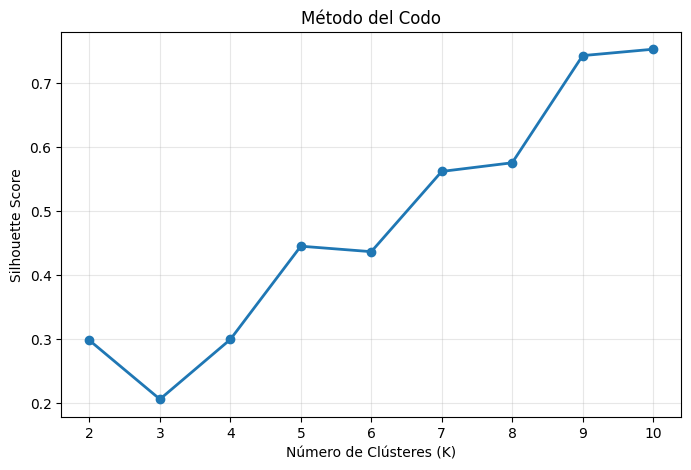

In [ ]:

import matplotlib.pyplot as plt

k_values = [x[0] for x in costos]
scores = [x[1] for x in costos]

plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    scores,
    marker='o',
    linewidth=2
)

plt.title("Método del Codo")
plt.xlabel("Número de Clústeres (K)")
plt.ylabel("Silhouette Score")

plt.grid(alpha=0.3)

plt.show()



In [ ]:

from pyspark.sql.functions import avg, count

# Modelo final
kmeans_final = KMeans(
    featuresCol="pca_features",
    k=3,
    seed=1
)

# Entrenar modelo
modelo_final = kmeans_final.fit(df_pca)

# Generar clusters
df_clusters = modelo_final.transform(df_pca)

# Resultados
df_clusters.select(
    "departamento",
    "municipio",
    "numeroatenciones",
    "prediction"
).show(20, truncate=False)

# Resumen clusters
cluster_summary = df_clusters.groupBy("prediction") \
    .agg(
        avg("numeroatenciones").alias("promedio_atenciones"),
        count("*").alias("cantidad_registros")
    )

cluster_summary.show()



+-----------------+-----------------------------------+----------------+----------+
|departamento     |municipio                          |numeroatenciones|prediction|
+-----------------+-----------------------------------+----------------+----------+
|08 - Atlántico   |08001 - Barranquilla               |1               |0         |
|05 - Antioquia   |05284 - Frontino                   |1               |1         |
|18 - Caquetá     |18029 - Albania                    |1               |0         |
|23 - Córdoba     |23807 - Tierralta                  |1               |0         |
|13 - Bolívar     |13001 - Cartagena                  |1               |2         |
|23 - Córdoba     |23090 - Canalete                   |1               |0         |
|15 - Boyacá      |15759 - Sogamoso                   |2               |0         |
|13 - Bolívar     |13667 - San Martín De Loba         |2               |0         |
|19 - Cauca       |19318 - Guapi                      |2               |0   

La segmentación con K-Means permitió identificar tres grupos principales de municipios según el comportamiento de las atenciones médicas.

* Clúster 0:
  Es el grupo con mayor cantidad de registros (130,224) y presenta un promedio de 90 atenciones. Representa municipios con demanda intermedia de servicios de salud.

* Clúster 1:
  Tiene el promedio de atenciones más alto (231.94), lo que indica municipios o ciudades con alta concentración de servicios médicos y mayor demanda en salud.

* Clúster 2:
  Presenta el promedio más bajo de atenciones (18.91), agrupando municipios con menor actividad o menor volumen de atención médica.

En general, los clústeres evidencian diferencias importantes en la distribución y concentración de las atenciones entre municipios del país.


## PARTE C

In [ ]:

from pyspark.sql.functions import when

# Crear label
df_ml = df.withColumn(
    "label",
    when(df["numeroatenciones"] >= 100, 1).otherwise(0)
)

# Ver clases
df_ml.groupBy("label").count().show()



+-----+------+
|label| count|
+-----+------+
|    1| 11616|
|    0|188384|
+-----+------+



In [ ]:

from pyspark.ml.feature import (
    StringIndexer,
    OneHotEncoder,
    VectorAssembler,
    StandardScaler
)

from pyspark.ml import Pipeline

# Variables categóricas
columnas_categoricas = [
    "departamento",
    "municipio",
    "tipoatencion"
]

# Indexadores
indexadores = [

    StringIndexer(
        inputCol=col,
        outputCol=f"{col}_index"
    )

    for col in columnas_categoricas
]

# One Hot Encoding
encoder = OneHotEncoder(
    inputCols=[
        f"{col}_index"
        for col in columnas_categoricas
    ],

    outputCols=[
        f"{col}_vec"
        for col in columnas_categoricas
    ]
)

# Variables numéricas
assembler_num = VectorAssembler(
    inputCols=["numeroatenciones"],
    outputCol="numerical_features"
)

# Escalamiento
scaler = StandardScaler(
    inputCol="numerical_features",
    outputCol="scaled_numerical_features"
)

# Variables finales
assembler = VectorAssembler(
    inputCols=[
        "departamento_vec",
        "municipio_vec",
        "tipoatencion_vec",
        "scaled_numerical_features"
    ],

    outputCol="features"
)

# Pipeline
pipeline = Pipeline(stages=

    indexadores +

    [
        encoder,
        assembler_num,
        scaler,
        assembler
    ]
)

# Entrenar pipeline
pipeline_model = pipeline.fit(df_ml)

# Transformar datos
df_final = pipeline_model.transform(df_ml)

# Resultado
df_final.select(
    "features",
    "label"
).show(5, truncate=False)



+---------------------------------------------------------+-----+
|features                                                 |label|
+---------------------------------------------------------+-----+
|(560,[5,12,559],[1.0,1.0,1.4810771265782576E-4])         |0    |
|(560,[0,56,556,559],[1.0,1.0,1.0,1.4810771265782576E-4]) |0    |
|(560,[9,291,557,559],[1.0,1.0,1.0,1.4810771265782576E-4])|0    |
|(560,[1,24,557,559],[1.0,1.0,1.0,1.4810771265782576E-4]) |0    |
|(560,[3,15,558,559],[1.0,1.0,1.0,1.4810771265782576E-4]) |0    |
+---------------------------------------------------------+-----+
only showing top 5 rows


In [ ]:

# División train/test
train_data, test_data = df_final.randomSplit(
    [0.8, 0.2],
    seed=123
)

print("Entrenamiento:", train_data.count())
print("Testeo :", test_data.count())



Entrenamiento: 160249
Testeo : 39751


In [ ]:

from pyspark.ml.classification import LogisticRegression

# Modelo
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label"
)

# Entrenar
lr_model = lr.fit(train_data)

# Predicciones
lr_predictions = lr_model.transform(test_data)

# Resultado
lr_predictions.select(
    "label",
    "prediction",
    "probability"
).show(10, truncate=False)



+-----+----------+-------------------------------------------+
|label|prediction|probability                                |
+-----+----------+-------------------------------------------+
|1    |1.0       |[4.363026177972486E-35,1.0]                |
|0    |0.0       |[0.9999999985576642,1.4423358063453406E-9] |
|1    |1.0       |[9.56996077742725E-66,1.0]                 |
|1    |1.0       |[1.0654459248117847E-10,0.9999999998934554]|
|1    |1.0       |[3.685339590919455E-19,1.0]                |
|0    |0.0       |[0.9999999997694677,2.3053225994829063E-10]|
|0    |0.0       |[0.9933095962555483,0.006690403744451734]  |
|0    |0.0       |[0.9999999998542366,1.4576340134908605E-10]|
|0    |0.0       |[0.9999999998840938,1.1590617354784172E-10]|
|0    |0.0       |[0.9999999999078353,9.216472030004752E-11] |
+-----+----------+-------------------------------------------+
only showing top 10 rows


In [ ]:

from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator,
    BinaryClassificationEvaluator
)

# Accuracy
accuracy = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
).evaluate(lr_predictions)

# Precision
precision = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
).evaluate(lr_predictions)

# Recall
recall = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
).evaluate(lr_predictions)

# F1
f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
).evaluate(lr_predictions)

# AUC
auc = BinaryClassificationEvaluator(
    labelCol="label"
).evaluate(lr_predictions)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")



Accuracy : 0.9981
Precision: 0.9981
Recall   : 0.9981
F1 Score : 0.9981
AUC      : 0.9913


In [ ]:

from pyspark.ml.classification import RandomForestClassifier

# Modelo
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=50
)

# Entrenar
rf_model = rf.fit(train_data)

# Predicciones
rf_predictions = rf_model.transform(test_data)

# Resultado
rf_predictions.select(
    "label",
    "prediction",
    "probability"
).show(10, truncate=False)


+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|1    |0.0       |[0.820290882028103,0.17970911797189704] |
|0    |0.0       |[0.9499244114181532,0.05007558858184678]|
|1    |0.0       |[0.820290882028103,0.17970911797189704] |
|1    |0.0       |[0.8238351334755802,0.17616486652441976]|
|1    |0.0       |[0.820290882028103,0.17970911797189704] |
|0    |0.0       |[0.9499244114181532,0.05007558858184678]|
|0    |0.0       |[0.9499244114181532,0.05007558858184678]|
|0    |0.0       |[0.9499244114181532,0.05007558858184678]|
|0    |0.0       |[0.9499244114181532,0.05007558858184678]|
|0    |0.0       |[0.9499244114181532,0.05007558858184678]|
+-----+----------+----------------------------------------+
only showing top 10 rows


In [ ]:

# Accuracy
accuracy_rf = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
).evaluate(rf_predictions)

# Precision
precision_rf = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
).evaluate(rf_predictions)

# Recall
recall_rf = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
).evaluate(rf_predictions)

# F1
f1_rf = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
).evaluate(rf_predictions)

# AUC
auc_rf = BinaryClassificationEvaluator(
    labelCol="label"
).evaluate(rf_predictions)

print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")
print(f"AUC      : {auc_rf:.4f}")



Accuracy : 0.9420
Precision: 0.8873
Recall   : 0.9420
F1 Score : 0.9138
AUC      : 0.9976


In [ ]:

from pyspark.mllib.evaluation import MulticlassMetrics

# Convertir predicciones
preds_lr = lr_predictions.select(
    "prediction",
    "label"
).rdd.map(lambda x: (float(x[0]), float(x[1])))

# Métricas
metrics_lr = MulticlassMetrics(preds_lr)

# Matriz de confusión
confusion_lr = metrics_lr.confusionMatrix().toArray()

print("Matriz de Confusión - Logistic Regression\n")
print(confusion_lr)



Matriz de Confusión - Logistic Regression

[[3.7422e+04 2.3000e+01]
 [5.3000e+01 2.2530e+03]]


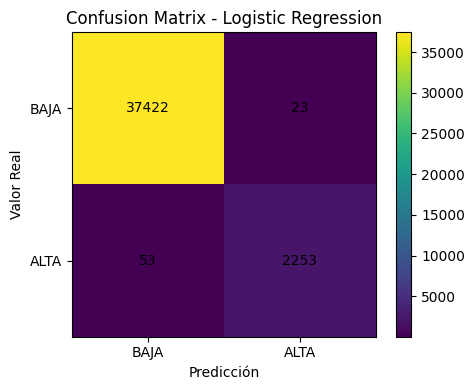

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(5,4))

plt.imshow(confusion_lr)

plt.title("Confusion Matrix - Logistic Regression")
plt.colorbar()

classes = ["BAJA", "ALTA"]

tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

for i in range(len(classes)):

    for j in range(len(classes)):

        plt.text(
            j,
            i,
            int(confusion_lr[i, j]),
            ha="center",
            va="center"
        )

plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.tight_layout()

plt.show()



In [ ]:

# Convertir predicciones
preds_rf = rf_predictions.select(
    "prediction",
    "label"
).rdd.map(lambda x: (float(x[0]), float(x[1])))

# Métricas
metrics_rf = MulticlassMetrics(preds_rf)

# Matriz de confusión
confusion_rf = metrics_rf.confusionMatrix().toArray()

print("Matriz de Confusión - Random Forest\n")
print(confusion_rf)



Matriz de Confusión - Random Forest

[[37445.     0.]
 [ 2306.     0.]]


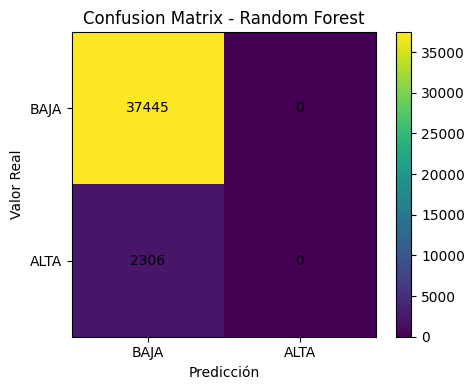

In [ ]:

plt.figure(figsize=(5,4))

plt.imshow(confusion_rf)

plt.title("Confusion Matrix - Random Forest")
plt.colorbar()

classes = ["BAJA", "ALTA"]

tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

for i in range(len(classes)):

    for j in range(len(classes)):

        plt.text(
            j,
            i,
            int(confusion_rf[i, j]),
            ha="center",
            va="center"
        )

plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.tight_layout()

plt.show()



                                         Variable  Importancia
559                   scaled_numerical_features_0     0.871202
10             departamento_vec_11 - Bogotá, D.C.     0.059950
12             municipio_vec_08001 - Barranquilla     0.032418
558                    tipoatencion_vec_URGENCIAS     0.008464
21                   municipio_vec_05360 - Itagui     0.006198
..                                            ...          ...
197  municipio_vec_18753 - San Vicente Del Caguán     0.000000
196               municipio_vec_17524 - Palestina     0.000000
195                   municipio_vec_05847 - Urrao     0.000000
194            municipio_vec_05697 - El Santuario     0.000000
280              municipio_vec_05667 - San Rafael     0.000000

[560 rows x 2 columns]


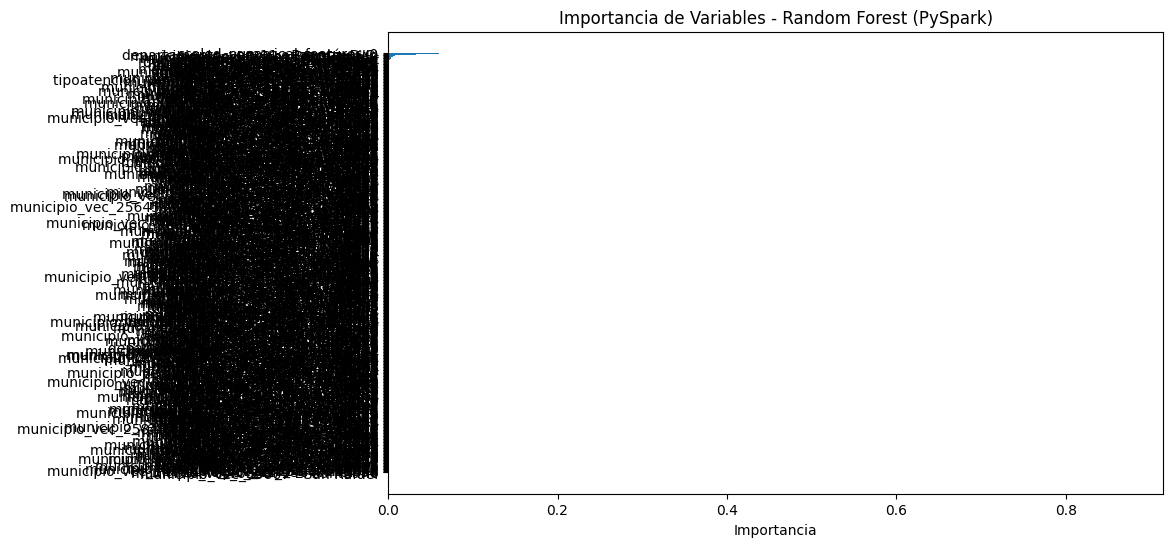

In [ ]:
mportances = rf_model.featureImportances.toArray()

# 🔥 ESTA ES LA FORMA CORRECTA EN SPARK
attrs = train_data.schema["features"].metadata["ml_attr"]["attrs"]

# extraer nombres en orden correcto
feature_cols = []
for key in attrs:
    for item in attrs[key]:
        feature_cols.append(item["name"])

# =========================
# 3. DATAFRAME
# =========================
df_importance = pd.DataFrame({
    "Variable": feature_cols,
    "Importancia": importances
})

df_importance = df_importance.sort_values(
    by="Importancia",
    ascending=False
)

print(df_importance)

# =========================
# 4. GRÁFICO
# =========================
plt.figure(figsize=(10,6))
plt.barh(df_importance["Variable"], df_importance["Importancia"])
plt.gca().invert_yaxis()
plt.title("Importancia de Variables - Random Forest (PySpark)")
plt.xlabel("Importancia")
plt.show()

**El modelo Random Forest muestra una fuerte dependencia de una variable numérica escalada, la cual concentra la mayor parte del poder predictivo (87%). Adicionalmente, algunas variables geográficas como el departamento y municipio aportan información relevante, aunque en menor medida. Sin embargo, la mayoría de las variables categóricas presentan importancia nula o cercana a cero, lo que sugiere que no contribuyen significativamente a la capacidad de predicción del modelo.**

# Conclusiones del ejercicio

* La Regresión Logística mostró un desempeño muy superior al Random Forest, logrando clasificar correctamente tanto los casos de nivel BAJO como los de nivel ALTO, con muy pocos errores de clasificación.

* En la matriz de confusión de la Regresión Logística se observa que el modelo identificó correctamente 37,422 casos BAJA y 2,253 casos ALTA, evidenciando una alta capacidad predictiva y un buen equilibrio entre ambas clases.

* El modelo Random Forest presentó un problema importante de sesgo hacia la clase BAJA, ya que clasificó prácticamente todos los registros como BAJA y no logró identificar correctamente los casos ALTA.

* Aunque el Random Forest obtuvo métricas globales relativamente altas, la matriz de confusión demuestra que el modelo no generaliza adecuadamente para la clase minoritaria, lo que evidencia un efecto del desbalance de clases en el dataset.

* Los resultados indican que la Regresión Logística fue el modelo más adecuado para este problema de clasificación, mientras que Random Forest requeriría técnicas adicionales como balanceo de clases, ajuste de hiperparámetros o redefinición del target para mejorar su desempeño.


# Parte D

In [ ]:
df_ml.show(5)

+--------------+--------------------+----+--------------------+--------------------+----------------+-----+
|  departamento|           municipio| a_o|        tipoatencion|         diagnostico|numeroatenciones|label|
+--------------+--------------------+----+--------------------+--------------------+----------------+-----+
|08 - Atlántico|08001 - Barranquilla|2019|   HOSPITALIZACIONES|D321 - TUMOR BENI...|               1|    0|
|05 - Antioquia|    05284 - Frontino|2019|           CONSULTAS|E343 - ENANISMO, ...|               1|    0|
|  18 - Caquetá|     18029 - Albania|2019|PROCEDIMIENTOS DE...|Z391 - ATENCION Y...|               1|    0|
|  23 - Córdoba|   23807 - Tierralta|2019|PROCEDIMIENTOS DE...|X944 - AGRESION C...|               1|    0|
|  13 - Bolívar|   13001 - Cartagena|2019|           URGENCIAS|I456 - SINDROME D...|               1|    0|
+--------------+--------------------+----+--------------------+--------------------+----------------+-----+
only showing top 5 rows


In [ ]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# indexacion
departamento_index = StringIndexer(inputCol="departamento", outputCol="departamento_idx")
municipio_index = StringIndexer(inputCol="municipio", outputCol="municipio_idx")
tipo_index = StringIndexer(inputCol="tipoatencion", outputCol="tipo_idx")
diagnostico_index = StringIndexer(inputCol="diagnostico", outputCol="diag_idx")

# encoding
encoder = OneHotEncoder(
    inputCols=["departamento_idx", "municipio_idx", "tipo_idx", "diag_idx"],
    outputCols=["departamento_vec", "municipio_vec", "tipo_vec", "diag_vec"]
)

# features
assembler = VectorAssembler(
    inputCols=[
        "a_o",
        "numeroatenciones",
        "departamento_vec",
        "municipio_vec",
        "tipo_vec",
        "diag_vec"
    ],
    outputCol="features"
)

# modelo
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label"
)

# grid hiperparametros
paramGrid = (ParamGridBuilder()
    .addGrid(rf.numTrees, [20, 50, 100])
    .addGrid(rf.maxDepth, [5, 10])
    .build()
)

# evaluador
evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    metricName="areaUnderROC"
)

# transformacion datos
df_prepared = departamento_index.fit(df_ml).transform(df_ml)
df_prepared = municipio_index.fit(df_prepared).transform(df_prepared)
df_prepared = tipo_index.fit(df_prepared).transform(df_prepared)
df_prepared = diagnostico_index.fit(df_prepared).transform(df_prepared)

df_prepared = encoder.fit(df_prepared).transform(df_prepared)

df_prepared = assembler.transform(df_prepared)

# cross validation
crossval = CrossValidator(
    estimator=rf,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=5,
    parallelism=2
)

# entrenamiento
cv_model = crossval.fit(df_prepared)

# mejor modelo
best_model = cv_model.bestModel

# mejor AUC
best_auc = max(cv_model.avgMetrics)
print("Mejor AUC:", best_auc)

# parametros optimos
print("NumTrees:", best_model.getNumTrees)
print("MaxDepth:", best_model._java_obj.getMaxDepth())

# predicciones
predictions = best_model.transform(df_prepared)

predictions.select(
    "label",
    "prediction",
    "probability"
).show(10, truncate=False)

Mejor AUC: 0.9979865489189332
NumTrees: 100
MaxDepth: 10
+-----+----------+-----------------------------------------+
|label|prediction|probability                              |
+-----+----------+-----------------------------------------+
|0    |0.0       |[0.9427390301246925,0.0572609698753076]  |
|0    |0.0       |[0.9478907588347412,0.052109241165258925]|
|0    |0.0       |[0.9490796016273885,0.05092039837261148] |
|0    |0.0       |[0.9510486590576107,0.04895134094238931] |
|0    |0.0       |[0.95108240393977,0.04891759606022998]   |
|0    |0.0       |[0.9511080691636118,0.048891930836388146]|
|0    |0.0       |[0.9482619370901613,0.05173806290983876] |
|0    |0.0       |[0.9497607522235766,0.050239247776423426]|
|0    |0.0       |[0.9494224320851369,0.05057756791486314] |
|0    |0.0       |[0.9509266359175755,0.04907336408242449] |
+-----+----------+-----------------------------------------+
only showing top 10 rows
